<a href="https://colab.research.google.com/github/dandanakaka/DeepLearningLab/blob/main/DeepLearningLab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Ensure reproducible splits
torch.manual_seed(42)

# Set CPU/GPU device (optimized for CPU lab environments)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from torchvision import datasets

dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="category", download=True
)

100%|██████████| 792M/792M [00:30<00:00, 26.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.8MB/s]


In [ ]:
DATA_DIR = "./data"

# Transforms with standard ImageNet statistics
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 1. Download full trainval pool and untouched test set
full_trainval = datasets.OxfordIIITPet(
    root=DATA_DIR, split="trainval", target_types="category", download=True
)
test_dataset_raw = datasets.OxfordIIITPet(
    root=DATA_DIR, split="test", target_types="category", download=True
)

# 2. Split trainval into 80% Train and 20% Validation
val_size = int(len(full_trainval) * 0.2)
train_size = len(full_trainval) - val_size
train_subset, val_subset = random_split(
    full_trainval, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 3. Custom wrapper to apply transforms separately to splits
class TransformedDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y

train_dataset = TransformedDataset(train_subset, train_transform)
val_dataset = TransformedDataset(val_subset, eval_transform)
test_dataset = TransformedDataset(test_dataset_raw, eval_transform)

# 4. DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset split complete:")
print(f"  • Training samples   : {len(train_dataset)}")
print(f"  • Validation samples : {len(val_dataset)}")
print(f"  • Test samples       : {len(test_dataset)} (Held out)")

Dataset split complete:
  • Training samples   : 2944
  • Validation samples : 736
  • Test samples       : 3669 (Held out)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

def set_initialization(model, mode = "zero"):
  def init_fn(m):
        # 1. Conv2d and Linear Layers
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if mode == "zero":
                nn.init.zeros_(m.weight)  # Overwrites existing values with 0.0
            elif mode == "random":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)  # Overwrites with N(0, 0.02)
            elif mode == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif mode == "he":
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

            # Reset bias if present
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        # 2. BatchNorm Layers
        elif isinstance(m, nn.BatchNorm2d):
            if mode == "zero":
                nn.init.zeros_(m.weight)  # gamma = 0
            else:
                nn.init.ones_(m.weight)   # gamma = 1
            nn.init.zeros_(m.bias)        # beta = 0

  model.apply(init_fn)

In [ ]:
##Weight initializaiton function

import torch.nn as nn

def apply_weight_initialization(model, mode="he"):
    """
    Applies the chosen weight initialization strategy across Conv2d, Linear,
    and BatchNorm2d modules in the model.

    Modes supported: 'zero', 'random', 'xavier', 'he'
    """
    for m in model.modules():
        # 1. Convolutional and Fully-Connected Layers
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if mode == "zero":
                nn.init.zeros_(m.weight)

            elif mode == "random":
                # Standard Normal distribution: N(mean=0.0, std=0.02)
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

            elif mode == "xavier":
                # Xavier / Glorot Uniform (designed for symmetric/tanh activations)
                nn.init.xavier_uniform_(m.weight)

            elif mode == "he":
                # He / Kaiming Normal (scaled specifically for ReLU/ReLU6 activations)
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

            # Zero out additive biases if present
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        # 2. Batch Normalization Layers (Scale gamma and Shift beta)
        elif isinstance(m, nn.BatchNorm2d):
            if mode == "zero":
                nn.init.zeros_(m.weight)  # gamma = 0
            else:
                nn.init.ones_(m.weight)   # gamma = 1
            nn.init.zeros_(m.bias)        # beta = 0

In [ ]:
from torchvision import models

# 1. Instantiate MobileNetV2 and set classifier to 37 classes
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.last_channel, 37)

# 2. Overwrite weights with your chosen strategy ('zero', 'random', 'xavier', or 'he')
apply_weight_initialization(model, mode="zero")

In [ ]:
import torch

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, (correct / total) * 100.0


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, (correct / total) * 100.0

In [ ]:
import copy
import torch.optim as optim

EPOCHS = 5
INIT_MODES = ["zero", "random", "xavier", "he"]

benchmark_history = {}
best_checkpoints = {}

for mode in INIT_MODES:
    print(f"\n{'='*25} Training with: {mode.upper()} {'='*25}")

    # 1. Instantiate fresh model & apply strategy
    model = models.mobilenet_v2(weights=None)
    model.classifier[1] = nn.Linear(model.last_channel, 37)
    apply_weight_initialization(model, mode=mode)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0

    for epoch in range(1, EPOCHS + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)

        # Save best performing checkpoint for test evaluation
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_checkpoints[mode] = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch}/{EPOCHS}] | Train Loss: {t_loss:.4f} (Acc: {t_acc:.2f}%) | Val Loss: {v_loss:.4f} (Val Acc: {v_acc:.2f}%)")

    benchmark_history[mode] = history


========================= Training with: ZERO =========================
Epoch [1/5] | Train Loss: 3.6114 (Acc: 2.51%) | Val Loss: 3.6118 (Val Acc: 1.77%)
Epoch [2/5] | Train Loss: 3.6111 (Acc: 2.41%) | Val Loss: 3.6124 (Val Acc: 1.77%)
Epoch [3/5] | Train Loss: 3.6109 (Acc: 2.65%) | Val Loss: 3.6129 (Val Acc: 1.77%)
Epoch [4/5] | Train Loss: 3.6108 (Acc: 2.96%) | Val Loss: 3.6137 (Val Acc: 1.77%)
Epoch [5/5] | Train Loss: 3.6107 (Acc: 2.96%) | Val Loss: 3.6141 (Val Acc: 1.77%)

========================= Training with: RANDOM =========================
Epoch [1/5] | Train Loss: 3.6635 (Acc: 4.65%) | Val Loss: 3.5770 (Val Acc: 6.79%)
Epoch [2/5] | Train Loss: 3.4322 (Acc: 7.37%) | Val Loss: 3.4505 (Val Acc: 8.29%)
Epoch [3/5] | Train Loss: 3.3347 (Acc: 8.80%) | Val Loss: 3.6368 (Val Acc: 7.74%)
Epoch [4/5] | Train Loss: 3.2419 (Acc: 10.63%) | Val Loss: 4.0364 (Val Acc: 8.02%)
Epoch [5/5] | Train Loss: 3.1546 (Acc: 11.89%) | Val Loss: 3.3233 (Val Acc: 8.83%)

========================= Tra


==================== UNTOUCHED TEST SET RESULTS ====================
Strategy: ZERO     | Test Loss: 3.6109 | Test Accuracy: 2.73%
Strategy: RANDOM   | Test Loss: 3.3296 | Test Accuracy: 10.25%
Strategy: XAVIER   | Test Loss: 3.2609 | Test Accuracy: 12.35%
Strategy: HE       | Test Loss: 3.3733 | Test Accuracy: 10.38%


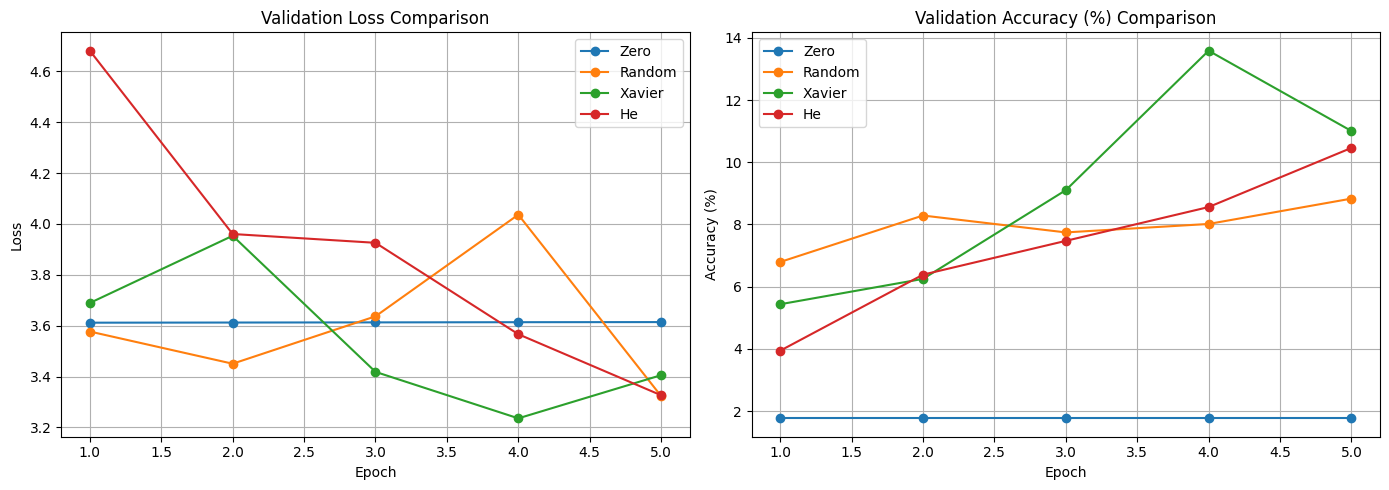

In [ ]:
import matplotlib.pyplot as plt

# 1. Evaluate on untouched Test set
print(f"\n{'='*20} UNTOUCHED TEST SET RESULTS {'='*20}")
test_criterion = nn.CrossEntropyLoss()

for mode in INIT_MODES:
    test_model = models.mobilenet_v2(weights=None)
    test_model.classifier[1] = nn.Linear(test_model.last_channel, 37)
    test_model.load_state_dict(best_checkpoints[mode])
    test_model.to(device)

    test_loss, test_acc = evaluate(test_model, test_loader, test_criterion, device)
    print(f"Strategy: {mode.upper():<8} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

# 2. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for mode, hist in benchmark_history.items():
    ax1.plot(range(1, EPOCHS + 1), hist["val_loss"], marker='o', label=mode.capitalize())
    ax2.plot(range(1, EPOCHS + 1), hist["val_acc"], marker='o', label=mode.capitalize())

ax1.set_title("Validation Loss Comparison")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend()

ax2.set_title("Validation Accuracy (%) Comparison")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()